In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
import tensorflow as tf

In [2]:
print(tf.__version__)

2.3.0


In [3]:
#pip install scipy

In [4]:
import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
#tf
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
df = pd.read_csv("india_policy_impact_dataset.csv")

print(len(df))

20000


In [8]:
df.head()

,policy_text,policy_area,ministry,year,public_sentiment,impact_label
0,Small procedural adjustments were made in the ...,public safety,Ministry of Health and Family Welfare,2023,Negative,Low Impact
1,The central government introduces a large-scal...,digital governance,Ministry of Housing and Urban Affairs,2017,Neutral,High Impact
2,Small procedural adjustments were made in the ...,digital governance,Ministry of Road Transport and Highways,2010,Negative,Low Impact
3,The policy updates documentation rules related...,agriculture,Ministry of Housing and Urban Affairs,2017,Neutral,Low Impact
4,Local authorities revised guidelines for handl...,public safety,Ministry of Electronics and IT,2018,Negative,Low Impact


In [9]:
print(df.isnull().sum())

print("COLUMNS ", df.columns)

print("INFO ",df.info())

policy_text         0
policy_area         0
ministry            0
year                0
public_sentiment    0
impact_label        0
dtype: int64
COLUMNS  Index(['policy_text', 'policy_area', 'ministry', 'year', 'public_sentiment',
       'impact_label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   policy_text       20000 non-null  object
 1   policy_area       20000 non-null  object
 2   ministry          20000 non-null  object
 3   year              20000 non-null  int64 
 4   public_sentiment  20000 non-null  object
 5   impact_label      20000 non-null  object
dtypes: int64(1), object(5)
memory usage: 937.6+ KB
INFO  None


In [10]:
#clean txte


def clean(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()


df['clean_text'] = df['policy_text'].apply(clean)

In [11]:
#feature = df[['policy_text', 'policy_area', 'ministry', 'public_sentiment']]
#g_output = df['impact_label']

In [12]:
#Tfidf txttttt

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features = 8000, stop_words='english')
text_features = tfidf.fit_transform(df['clean_text'])

In [13]:
print(df['clean_text'].iloc[0])  # new
print(df['policy_text'].iloc[0])

small procedural adjustments were made in the management of public safety programs
Small procedural adjustments were made in the management of public safety programs.


In [14]:
cat_encoder = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
cat_features = cat_encoder.fit_transform(
    df[["policy_area", "ministry", "public_sentiment"]]
)

In [15]:
X = hstack([text_features, cat_features]).toarray().astype("float32")

In [16]:
label_enc = LabelEncoder()
y = label_enc.fit_transform(df["impact_label"]).astype("float32")

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(1, activation="sigmoid")
])

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 256)               80896     
_________________________________________________________________
batch_normalization (BatchNo (None, 256)               1024      
_________________________________________________________________
dropout (Dropout)            (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
batch_normalization_1 (Batch (None, 128)               512       
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 64)                8

In [21]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True)

In [22]:
print("\n Training...\n")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


 Training...

Epoch 1/50
225/225 [==============================] - 2s 7ms/step - loss: 0.0277 - accuracy: 0.9896 - val_loss: 0.0608 - val_accuracy: 1.0000
Epoch 2/50
225/225 [==============================] - 1s 6ms/step - loss: 3.8243e-04 - accuracy: 1.0000 - val_loss: 6.5884e-04 - val_accuracy: 1.0000
Epoch 3/50
225/225 [==============================] - 1s 3ms/step - loss: 1.1136e-04 - accuracy: 1.0000 - val_loss: 1.3469e-05 - val_accuracy: 1.0000
Epoch 4/50
225/225 [==============================] - 1s 5ms/step - loss: 6.9813e-05 - accuracy: 1.0000 - val_loss: 3.3836e-06 - val_accuracy: 1.0000
Epoch 5/50
225/225 [==============================] - 1s 6ms/step - loss: 4.0864e-05 - accuracy: 1.0000 - val_loss: 1.8706e-06 - val_accuracy: 1.0000
Epoch 6/50
225/225 [==============================] - 2s 11ms/step - loss: 2.7724e-05 - accuracy: 1.0000 - val_loss: 1.2131e-06 - val_accuracy: 1.0000
Epoch 7/50
225/225 [==============================] - 4s 16ms/step - loss: 2.8019e-05 - accu

In [23]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

In [24]:
print(f"\n{'='*45}")
print(f"  Test Accuracy : {acc:.2%}  |  Loss : {loss:.4f}")
print(f"{'='*45}")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))


  Test Accuracy : 100.00%  |  Loss : 0.0000
              precision    recall  f1-score   support

 High Impact       1.00      1.00      1.00      1995
  Low Impact       1.00      1.00      1.00      2005

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [27]:
#

<Axes: >

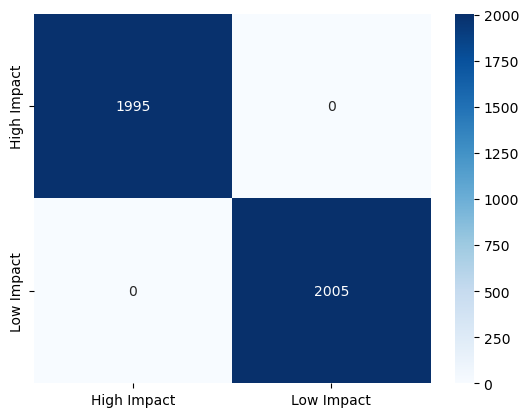

In [32]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
